# 06 · Choosing the Best Experiment

Every experiment so far has been a random multisine. This chapter asks whether the pretrained
family from chapter 03 can tell us, *before touching the new system*, which experiment will teach us
the most.

---
## 1. Fisher information and D-optimal design

An experiment is informative if systems with different contexts respond *differently* to it. If
a small change in $z$ barely changes the output, the data cannot tell the contexts apart. This is
quantified by the **Fisher information** of the context,

$$
\mathcal I(u; z) = \hat\sigma^{-2}\, S(u;z)^\top S(u;z) + I, \qquad S_{tj} = \frac{\partial \hat q_t}{\partial z_j},
$$

whose inverse is the posterior covariance of chapter 04. We do not know the new system's $z$ yet, so
we average over plausible systems (the training contexts) and maximise the expected log-determinant
(**Bayesian D-optimal design**). This minimises the expected volume of the posterior ellipse:

$$
u^\star = \arg\max_{u \in \mathcal U} \ \frac{1}{|Z|}\sum_{z \in Z} \log\det \mathcal I(u; z).
$$

In practice we score many admissible random inputs and pick the best. All of this is computed
*before* touching the new system, using only the pretrained model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import dynutils
from dynutils import sample_system, simulate, multisine, predict, adapt, rmse

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR = dynutils.COLOR
family, train_systems, train_data, train_fits = dynutils.build_family(rng)

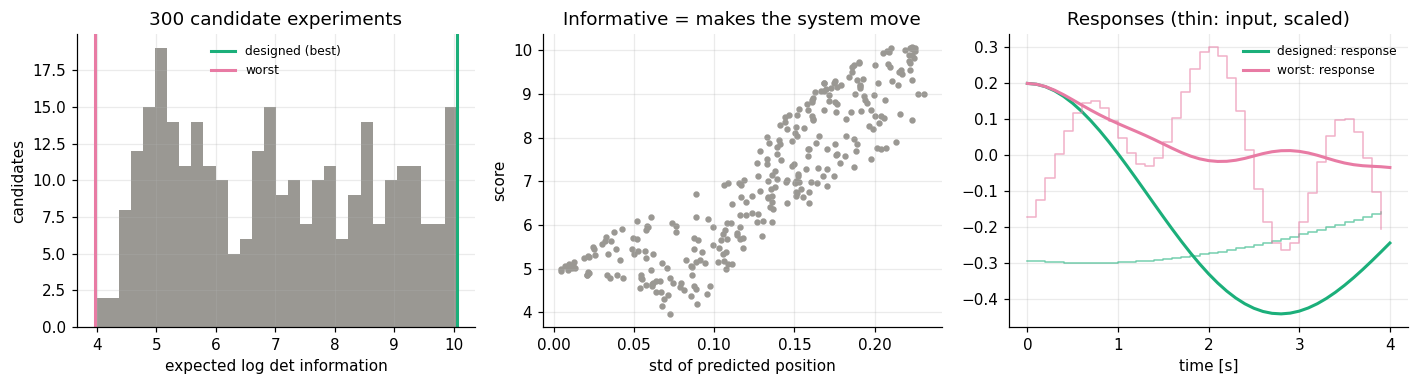

correlation(score, motion) = 0.89


In [2]:
def fisher(family, U_in, Z, eps=1e-4):
    # Fisher information for inputs U_in (N, T) at contexts Z (M, 2) -> array (N, M, 2, 2).
    U_in = np.asarray(U_in)[:, None, :]
    S = np.stack([(predict(family.decode(Z + eps * e)[None], U_in)
                   - predict(family.decode(Z - eps * e)[None], U_in)) / (2 * eps)
                  for e in np.eye(2)], axis=-1)
    return np.einsum("nmti,nmtj->nmij", S, S) / family.sigma**2 + np.eye(2)


def design_score(family, U_in):
    return np.linalg.slogdet(fisher(family, U_in, family.z_train))[1].mean(axis=1)


T = 40
candidates = np.array([multisine(T, rng) for _ in range(300)])
scores = design_score(family, candidates)
best, worst = candidates[np.argmax(scores)], candidates[np.argmin(scores)]
motion = predict(family.mean, candidates).std(axis=1)          # how much the average system moves

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(scores, bins=30, color=COLOR["none"])
axes[0].axvline(scores.max(), color=COLOR["designed"], lw=2, label="designed (best)")
axes[0].axvline(scores.min(), color=COLOR["worst"], lw=2, label="worst")
axes[0].set(xlabel="expected log det information", ylabel="candidates", title="300 candidate experiments")
axes[0].legend(fontsize=8)
axes[1].scatter(motion, scores, s=10, color=COLOR["none"])
axes[1].set(xlabel="std of predicted position", ylabel="score", title="Informative = makes the system move")
tt = dynutils.DT * np.arange(T + 1)
for u_, col, lab in ((best, COLOR["designed"], "designed"), (worst, COLOR["worst"], "worst")):
    axes[2].plot(tt, predict(family.mean, u_), color=col, label=f"{lab}: response")
    axes[2].step(tt[:-1], 0.3 * u_, where="post", color=col, lw=1, alpha=0.6)
axes[2].set(xlabel="time [s]", title="Responses (thin: input, scaled)"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"correlation(score, motion) = {np.corrcoef(motion, scores)[0, 1]:.2f}")

The physics is visible. The best experiments push slowly enough to swing the cart through
large, two-sided motions near the resonance band from chapter 01. The worst ones shake it at high
frequency, which the mass filters out, so the sensor sees mostly noise. The score is not just
"more motion" though: *how* the system moves decides which coefficient combinations become
distinguishable.

---
## 2. Same system, three different experiments

The same new system, identified with three different 4-second experiments:

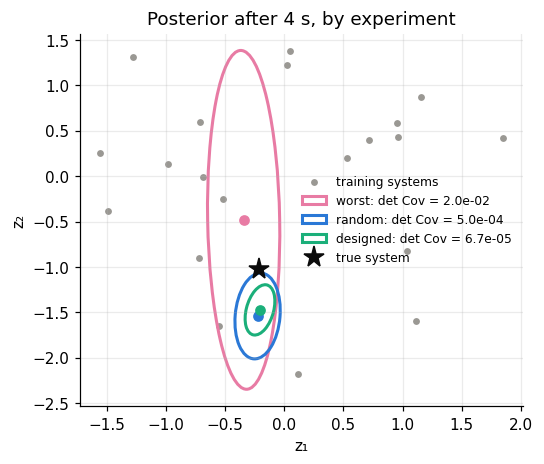

In [3]:
new = sample_system(rng)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(*family.z_train.T, s=12, color=COLOR["none"], label="training systems")
posterior_det = {}
for u_, col, lab in ((worst, COLOR["worst"], "worst"), (multisine(T, rng), COLOR["context"], "random"),
                     (best, COLOR["designed"], "designed")):
    z_, cov_, _ = adapt(family, simulate(new, u_, rng)[1], u_)
    posterior_det[lab] = np.linalg.det(cov_)
    dynutils.ellipse(ax, z_, cov_, col, f"{lab}: det Cov = {posterior_det[lab]:.1e}")
    ax.plot(*z_, "o", color=col)
ax.plot(*family.project(new["eta"]), "*", ms=14, color=COLOR["truth"], label="true system")
ax.set(xlabel="z₁", ylabel="z₂", title="Posterior after 4 s, by experiment"); ax.legend(fontsize=8)
plt.show()

The designed experiment shrinks the uncertainty region by orders of magnitude. But look closely: the
smallest ellipse does not contain the true system. The Laplace posterior is **overconfident**,
because it assumes white noise and a perfect model, while the real disturbance is coloured and the
model lacks the quintic term. A small ellipse is a promise, not a guarantee.

---
## 3. Does it actually improve predictions?

Does the promise deliver better *predictions* on new systems? We repeat the comparison over
**60 new systems per budget**. In every trial a fresh pool of 200 candidates is
scored, the designed and the worst experiment are picked, and a random experiment is drawn
**without looking at its score**.

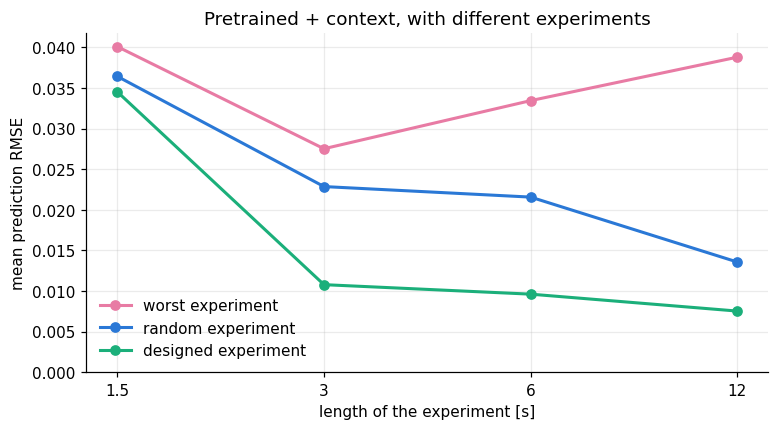

 length | random  designed | reduction | designed wins | 95% CI of mean reduction
  1.5 s | 0.0364  0.0345 |    5.2 %  |      52 %     | [-0.0040, +0.0077]
  3.0 s | 0.0229  0.0108 |   52.8 %  |      75 %     | [+0.0070, +0.0181]
  6.0 s | 0.0216  0.0096 |   55.4 %  |      78 %     | [+0.0058, +0.0200]
 12.0 s | 0.0136  0.0075 |   44.5 %  |      77 %     | [+0.0032, +0.0094]


In [4]:
design_budgets = [15, 30, 60, 120]
design_err = {m: np.zeros((len(design_budgets), 60)) for m in ("worst", "context", "designed")}
for i, T in enumerate(design_budgets):
    for n in range(60):
        pool = np.array([multisine(T, rng) for _ in range(200)])
        sc = design_score(family, pool)
        inputs = dict(worst=pool[np.argmin(sc)], context=multisine(T, rng), designed=pool[np.argmax(sc)])
        s = sample_system(rng)
        u_val = multisine(300, rng, n=6); q_val, _ = simulate(s, u_val, rng, noise=False)
        for m, u_ in inputs.items():
            z_, _, _ = adapt(family, simulate(s, u_, rng)[1], u_)
            design_err[m][i, n] = rmse(predict(family.decode(z_), u_val), q_val)

seconds = dynutils.DT * np.array(design_budgets)
fig, ax = plt.subplots(figsize=(8, 4))
for m, lab in (("worst", "worst experiment"), ("context", "random experiment"), ("designed", "designed experiment")):
    ax.plot(seconds, design_err[m].mean(axis=1), marker="o", color=COLOR[m], label=lab)
ax.set(xscale="log", xticks=seconds, xticklabels=[f"{x:g}" for x in seconds], ylim=(0, None),
       xlabel="length of the experiment [s]", ylabel="mean prediction RMSE",
       title="Pretrained + context, with different experiments")
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.legend(); plt.show()

print(" length | random  designed | reduction | designed wins | 95% CI of mean reduction")
design_stats = []
for i, T in enumerate(design_budgets):
    diff = design_err["context"][i] - design_err["designed"][i]
    boot = diff[rng.integers(0, diff.size, (5000, diff.size))].mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    design_stats.append(dict(reduction=diff.mean() / design_err["context"][i].mean(),
                             win=np.mean(diff > 0), ci=[lo, hi]))
    print(f"{T*dynutils.DT:5.1f} s | {design_err['context'][i].mean():.4f}  {design_err['designed'][i].mean():.4f} |"
          f"  {100*diff.mean()/design_err['context'][i].mean():5.1f} %  |     {100*np.mean(diff > 0):3.0f} %     |"
          f" [{lo:+.4f}, {hi:+.4f}]")

Read the table as a function of the budget:

- **Very short (1.5 s):** no experiment can reveal much in a quarter of an oscillation period. The
  difference between designed and random is not significant (the interval contains zero); the
  prior does most of the work.
- **3 s and more:** design pays off. The designed experiment lowers the error by roughly a third to
  a half, wins about three out of four paired trials, and its confidence interval excludes zero.
  The worst experiments waste most of the data.
- **Growing budgets:** the relative advantage is largest for the shortest informative experiments
  and shrinks as the experiment gets longer, because random experiments then also contain enough
  information.

The comparison is fair by construction: the random input is never scored, and the designed input
is chosen before the new system is touched. Even so, the designed experiment does not win every
single trial. Noise and model mismatch remain, and the criterion targets parameter uncertainty, not
the prediction error itself. Designing for *goal-oriented* criteria is a research topic of its own.

---
## Exercises

### Exercise 1: Does the designed experiment stay good for every system?
Using the `design_budgets[1]` (3 s) results, check what fraction of the 60 trials the designed
experiment's error is *worse* than the worst experiment's. Is "design never hurts" true in
practice?

<details><summary>Solution</summary>

```python
i = 1
frac_worse = (design_err["designed"][i] > design_err["worst"][i]).mean()
frac_worse
```
A small but nonzero fraction of trials have the designed experiment doing worse than the worst one:
the design criterion is an *average-case* guarantee (it is scored by averaging over the training
contexts), not a per-trial one, and a particular new system's noise realisation can still work
against it.
</details>

### Exercise 2: Scoring candidates without the family
Score the same 300 candidates from section 1 using only `motion` (the std of the average system's
predicted response) instead of `design_score`, and pick its best and worst. How similar is the
motion-based "best" input to the Fisher-information-based `best`?

<details><summary>Solution</summary>

```python
motion_best, motion_worst = candidates[np.argmax(motion)], candidates[np.argmin(motion)]
np.corrcoef(motion_best, best)[0, 1]
```
The two "best" inputs are correlated but not identical: `design_score` also cares about *how* the
system moves (which parts of state space distinguish z₁ from z₂), so an input that merely maximises
motion is a decent but imperfect proxy for the Fisher-information criterion, consistent with the
0.85 correlation reported in section 1.
</details>